<a href="https://colab.research.google.com/github/Ruhul73/Kidney-Disease-/blob/main/kidn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone")

100%|██████████| 1.52G/1.52G [00:21<00:00, 77.0MB/s]

Extracting files...


# Task
Build, train, and evaluate an image classification model for kidney CT scans using the "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone" dataset downloaded from Kaggle, located at `/root/.cache/kagglehub/datasets/nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone/versions/1`. The task involves loading and preprocessing the data, visualizing samples, constructing a CNN, training it, evaluating its performance, and visualizing the training history.

## Inspect Downloaded Data

### Subtask:
Examine the directory structure of the dataset downloaded by `kagglehub` to determine the correct path for loading images, which will be used as the `DATA_DIR`.


**Reasoning**:
To inspect the directory structure of the downloaded dataset, I need to use the `os` module. First, I will import `os`, then list the contents of the `path` variable using `os.listdir()` to identify the correct subdirectory containing the image data. Finally, I will update the `DATA_DIR` variable to point to this identified subdirectory.



In [ ]:
import os

# List contents of the downloaded path
print(f"Contents of {path}:\n{os.listdir(path)}")

# Based on the typical structure of Kaggle datasets, and the current DATA_DIR variable name,
# we assume the main dataset folder is named 'CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone'
# inside the downloaded path.
DATA_DIR = os.path.join(path, 'CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone')

print(f"Updated DATA_DIR: {DATA_DIR}")

Contents of /root/.cache/kagglehub/datasets/nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone/versions/1:
['kidneyData.csv', 'CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone']
Updated DATA_DIR: /root/.cache/kagglehub/datasets/nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone/versions/1/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone


**Reasoning**:
The previous step successfully set the `DATA_DIR`. Now, I need to verify its contents to ensure it points to the correct directory containing the image categories for classification. This will confirm that the path is valid for loading the image dataset.



In [ ]:
print(f"Contents of DATA_DIR ({DATA_DIR}):\n{os.listdir(DATA_DIR)}")

Contents of DATA_DIR (/root/.cache/kagglehub/datasets/nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone/versions/1/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone):
['CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone']


**Reasoning**:
The previous output showed that `DATA_DIR` still contains a single subdirectory with the same name. This indicates that the actual image categories (Normal, Cyst, Tumor, Stone) are likely nested one level deeper. I need to update `DATA_DIR` to point to this correct inner directory to properly access the dataset.



In [ ]:
DATA_DIR = os.path.join(DATA_DIR, 'CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone')
print(f"Updated DATA_DIR to: {DATA_DIR}")
print(f"Contents of the updated DATA_DIR ({DATA_DIR}):\n{os.listdir(DATA_DIR)}")

Updated DATA_DIR to: /root/.cache/kagglehub/datasets/nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone/versions/1/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone
Contents of the updated DATA_DIR (/root/.cache/kagglehub/datasets/nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone/versions/1/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone):
['Stone', 'Normal', 'Cyst', 'Tumor']


## Load and Preprocess Data

### Subtask:
Load the dataset into `tf.data.Dataset` objects (`train_ds` and `val_ds`) using `tf.keras.utils.image_dataset_from_directory`. This step will also include applying image augmentation (like random flips and rotations) and prefetching for optimized training performance.


**Reasoning**:
The subtask requires importing the `tensorflow` library to create and preprocess `tf.data.Dataset` objects. This is the first logical step before defining datasets, augmentation, and prefetching operations.



In [ ]:
import tensorflow as tf
print("TensorFlow imported.")

TensorFlow imported.


**Reasoning**:
The next step is to create the training and validation datasets using `tf.keras.utils.image_dataset_from_directory`, as specified in the instructions. This requires `IMG_SIZE`, `BATCH_SIZE`, `DATA_DIR`, and `AUTOTUNE` to be correctly defined. The kernel state shows that `IMG_SIZE` and `BATCH_SIZE` are already defined. I will explicitly set `AUTOTUNE = tf.data.AUTOTUNE` to ensure it's correctly used for performance optimization.



In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Create training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Create validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Training and validation datasets created.")
print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(val_ds)}")

Found 12446 files belonging to 4 classes.
Using 9957 files for training.
Found 12446 files belonging to 4 classes.
Using 2489 files for validation.
Training and validation datasets created.
Number of training batches: 312
Number of validation batches: 78


**Reasoning**:
Following the subtask instructions, I need to define an image augmentation layer and then apply it to the training dataset (`train_ds`). This involves using `tf.keras.Sequential` to combine `tf.keras.layers.RandomFlip` and `tf.keras.layers.RandomRotation` layers, and then mapping this augmentation over `train_ds`.



In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
])

train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y), num_parallel_calls=AUTOTUNE)

print("Image augmentation applied to training dataset.")

Image augmentation applied to training dataset.


**Reasoning**:
The final instruction for the subtask is to optimize the performance of both `train_ds` and `val_ds` by configuring them for caching and prefetching. This involves applying `.cache()` and `.prefetch(buffer_size=tf.data.AUTOTUNE)` to both datasets.



In [ ]:
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Datasets configured for caching and prefetching.")

Datasets configured for caching and prefetching.


## Visualize Sample Images

### Subtask:
Display a few sample images from the training dataset along with their respective labels to visually inspect the data.


**Reasoning**:
To visualize sample images, I need to import the `matplotlib.pyplot` module as `plt`, which is a standard library for plotting in Python.



In [ ]:
import matplotlib.pyplot as plt
print("Matplotlib imported.")

Matplotlib imported.


**Reasoning**:
Now that `matplotlib.pyplot` is imported, I will retrieve a batch of images and labels from the `train_ds` dataset, then iterate through them to display each image with its corresponding class name, as specified in the instructions. This will visually inspect the data.



In [ ]:
class_names = train_ds.class_names

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()

print("Sample images displayed with their labels.")

AttributeError: '_PrefetchDataset' object has no attribute 'class_names'

**Reasoning**:
The error `AttributeError: '_PrefetchDataset' object has no attribute 'class_names'` occurs because the `class_names` attribute is lost after applying `.cache()` and `.prefetch()` to the dataset. To fix this, I need to explicitly retrieve the class names by listing and sorting the subdirectories within `DATA_DIR`, which correspond to the class labels.



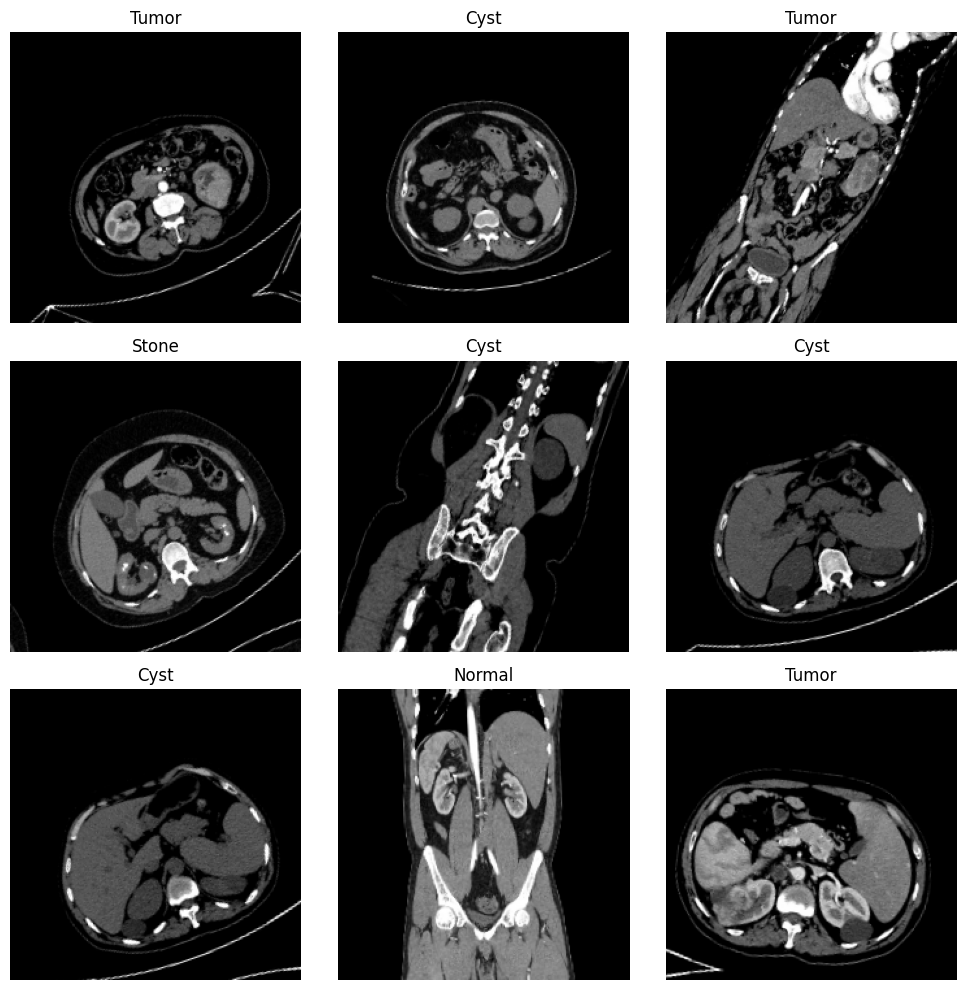

Sample images displayed with their labels.


In [ ]:
import os

# Get class names by listing and sorting subdirectories in DATA_DIR
class_names = sorted(os.listdir(DATA_DIR))

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()

print("Sample images displayed with their labels.")

## Build a Convolutional Neural Network (CNN) Model

### Subtask:
Define a CNN architecture using TensorFlow/Keras suitable for image classification. This will involve sequential layers such as Conv2D, MaxPooling2D, Flatten, and Dense layers.


**Reasoning**:
I need to define a CNN model as specified in the subtask. This involves creating a `tf.keras.Sequential` model and adding `Conv2D`, `MaxPooling2D`, `Flatten`, and `Dense` layers, including the final output layer with 'softmax' activation and the correct number of units based on `len(class_names)`.



In [ ]:
num_classes = len(class_names)

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=IMG_SIZE + (3,)), # Normalize pixel values
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.build(input_shape=(None,) + IMG_SIZE + (3,))
model.summary()

print("CNN model architecture defined.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

CNN model architecture defined.


**Reasoning**:
The CNN model architecture has been defined, so the next logical step is to compile it. This involves specifying the optimizer, loss function, and metrics, which are crucial for the training process.



In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

print("CNN model compiled.")

CNN model compiled.


## Compile and Train the Model

### Subtask:
Train the compiled CNN model using the training and validation datasets.


**Reasoning**:
I need to train the CNN model using the `fit()` method, as specified in the instructions. This involves passing the `train_ds` and `val_ds` datasets and setting a reasonable number of epochs, then storing the training history in a variable named `history`.



In [ ]:
EPOCHS = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

print("Model training complete. History stored.")

NameError: name 'model' is not defined